# Data Cleaning, Feature Engineering and Modeling | Customer Churn Risk Tool

## 1. Setup & Data Loading

In [208]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100,
})

# Fixed reference date for reproducibility
REFERENCE_DATE = pd.Timestamp('2026-08-18')
print(f"Reference date (fixed): {REFERENCE_DATE.date()}")

Reference date (fixed): 2026-08-18


In [209]:
# Load raw historical dataset
raw_df = pd.read_csv('../data/raw/historical_customers_ds.csv',
                        parse_dates=['signup_date', 'last_login_date'])

print(f"Raw dataset shape: {raw_df.shape}")
print(f"Columns: {list(raw_df.columns)}")
raw_df.head()

Raw dataset shape: (243, 10)
Columns: ['customer_id', 'signup_date', 'plan_type', 'monthly_spend', 'last_login_date', 'num_logins_30d', 'support_tickets_30d', 'cancelled_flag', 'preferred_language', 'internal_import_batch']


,customer_id,signup_date,plan_type,monthly_spend,last_login_date,num_logins_30d,support_tickets_30d,cancelled_flag,preferred_language,internal_import_batch
0,cust_0001,2024-02-15,Basic,17.97,2026-06-29,13.0,4.0,True,fr,import_05
1,cust_0002,2023-08-28,Enterprise,264.65,2026-06-18,18.0,3.0,False,en,import_03
2,cust_0003,2025-01-04,Professional,94.47,2026-07-26,21.0,2.0,False,fr,import_02
3,cust_0004,2025-04-03,Standard,44.93,2026-06-29,16.0,3.0,False,de,import_06
4,cust_0005,2022-12-15,Professional,95.40,2026-07-20,25.0,0.0,False,de,import_03


In [210]:
# Keep a copy for comparison later
original_shape = raw_df.shape
df = raw_df.copy()
print(f"Working copy created: {df.shape}")

Working copy created: (243, 10)


## 2. Data Cleaning Pipeline

Each cleaning step is documented with:
- **What** issue is being fixed
- **Why** the chosen action is appropriate
- **How** it's implemented

The order matters: **drop columns → drop rows → fix dates → impute values** — this ensures imputation medians are calculated on the cleanest possible data.

### 2.1 Drop `internal_import_batch` Column

| Detail | Value |
|--------|-------|
| **Issue** | System artifact column with no semantic value for churn prediction |
| **Rows affected** | All (243) |
| **Decision** | **Drop** — this column only indicates which data-import batch a record came from. It has no causal or correlational relationship with customer churn behavior. |

In [211]:
print(f"Unique values before drop: {df['internal_import_batch'].nunique()} → {df['internal_import_batch'].unique()}")
df = df.drop(columns=['internal_import_batch'])
print(f"Dropped 'internal_import_batch'. Shape: {df.shape}")

Unique values before drop: 8 → <ArrowStringArray>
['import_05', 'import_03', 'import_02', 'import_06', 'import_07', 'import_01',
 'import_04', 'import_08']
Length: 8, dtype: str
Dropped 'internal_import_batch'. Shape: (243, 9)


### 2.2 Remove Exact Duplicate Rows

| Detail | Value |
|--------|-------|
| **Issue** | 3 customer_ids appear twice with identical data across all columns — clearly import artifacts |
| **Rows affected** | 6 rows (3 pairs) — cust_0017, cust_0075, cust_0184 |
| **Decision** | **Drop duplicate** (keep first occurrence). Zero information is lost since both rows in each pair are identical. These are likely caused by double-import from the same batch. |

In [212]:
# Detect duplicates (all columns except customer_id)
cols_for_dup_check = [c for c in df.columns if c != 'customer_id']
dup_mask = df.duplicated(subset=cols_for_dup_check, keep=False)
print(f"Duplicate rows found (total): {dup_mask.sum()}")

if dup_mask.sum() > 0:
    print("\nDuplicated rows:")
    display(df[dup_mask].sort_values('customer_id')[['customer_id', 'plan_type', 'monthly_spend', 'cancelled_flag']])

# Drop duplicates, keep first
before = len(df)
df = df.drop_duplicates(subset=cols_for_dup_check, keep='first')
after = len(df)
print(f"\nRemoved {before - after} duplicate rows. Shape: {df.shape}")

Duplicate rows found (total): 6

Duplicated rows:


,customer_id,plan_type,monthly_spend,cancelled_flag
16,cust_0017,Professional,109.75,False
240,cust_0017,Professional,109.75,False
74,cust_0075,Standard,53.90,False
241,cust_0075,Standard,53.90,False
183,cust_0184,Standard,43.48,False
242,cust_0184,Standard,43.48,False



Removed 3 duplicate rows. Shape: (240, 9)


### 2.3 Drop Row with Future `signup_date`

| Detail | Value |
|--------|-------|
| **Issue** | cust_0140 has `signup_date = 2027-02-14` — 6 months in the future |
| **Why drop instead of impute** | The signup date is clearly wrong and causes a **cascade of inconsistencies**: the customer's last_login (2026-07-17) is *before* their supposed signup. There's no reliable way to recover the true signup date. Since this is only 1 row out of 240 and the customer is non-cancelled, dropping is safe and avoids injecting noise. |
| **Decision** | **Drop row entirely** |

In [213]:
# Detect future signup dates
future_signup = df[df['signup_date'] > REFERENCE_DATE]
print(f"Rows with future signup_date: {len(future_signup)}")
if len(future_signup) > 0:
    display(future_signup[['customer_id', 'signup_date', 'last_login_date', 'cancelled_flag']])

# Drop them
before = len(df)
df = df[df['signup_date'] <= REFERENCE_DATE]
print(f"\nDropped {before - len(df)} row(s) with future signup_date. Shape: {df.shape}")

Rows with future signup_date: 1


,customer_id,signup_date,last_login_date,cancelled_flag
139,cust_0140,2027-02-14,2026-07-17,False



Dropped 1 row(s) with future signup_date. Shape: (239, 9)


### 2.4 Flag Future `last_login_date` → Set to NaT

| Detail | Value |
|--------|-------|
| **Issue** | cust_0202 has `last_login_date = 2026-12-01` — ~4 months in the future |
| **Why not drop** | The rest of the customer's data is valid (valid signup, valid plan, valid spend). Only the login date is wrong. |
| **Decision** | **Flag → set to NaT**. The `days_since_last_login` derived feature will be NaN and imputed with the median in Section 3. This preserves the row while neutralizing the bad date. |

In [214]:
# Detect future last_login dates
future_login = df[df['last_login_date'] > REFERENCE_DATE]
print(f"Rows with future last_login_date: {len(future_login)}")
if len(future_login) > 0:
    display(future_login[['customer_id', 'signup_date', 'last_login_date']])

# Flag and set to NaT
df.loc[df['last_login_date'] > REFERENCE_DATE, 'last_login_date'] = pd.NaT
print(f"\nSet {len(future_login)} future last_login_date(s) to NaT. Will impute in feature engineering.")

Rows with future last_login_date: 1


,customer_id,signup_date,last_login_date
201,cust_0202,2025-01-25,2026-12-01



Set 1 future last_login_date(s) to NaT. Will impute in feature engineering.


### 2.5 Fix `last_login_date` Before `signup_date`

| Detail | Value |
|--------|-------|
| **Issue** | cust_0166: signed up 2026-07-10, last login 2026-06-20 — logged in 20 days *before* joining |
| **Why not drop** | The discrepancy is small (20 days) and could be a timezone or data entry error. The rest of the record is valid. |
| **Decision** | **Correct** — set `last_login_date = signup_date`. We assume the first meaningful activity happened on the signup day. This is conservative and avoids losing a data point. |

In [215]:
# Detect login before signup (only for rows with both dates present)
both_dates = df.dropna(subset=['signup_date', 'last_login_date'])
login_before = both_dates[both_dates['last_login_date'] < both_dates['signup_date']]
print(f"Rows with last_login_date before signup_date: {len(login_before)}")
if len(login_before) > 0:
    display(login_before[['customer_id', 'signup_date', 'last_login_date']])

# Fix: set last_login_date = signup_date
mask = (df['last_login_date'] < df['signup_date']) & df['last_login_date'].notna() & df['signup_date'].notna()
df.loc[mask, 'last_login_date'] = df.loc[mask, 'signup_date']
print(f"\nCorrected {mask.sum()} row(s): set last_login_date = signup_date.")

Rows with last_login_date before signup_date: 1


,customer_id,signup_date,last_login_date
165,cust_0166,2026-07-10,2026-06-20



Corrected 1 row(s): set last_login_date = signup_date.


### 2.6 Impute Negative `monthly_spend`

| Detail | Value |
|--------|-------|
| **Issue** | cust_0118 (−49.00, Basic) and cust_0223 (−9.99, Basic) have negative subscription spend |
| **Why impute, not drop** | Negative revenue is impossible for a subscription — these are likely refunds or data entry errors. But the customers' other data is valid and we have only ~240 rows, so dropping is wasteful. |
| **Decision** | **Set negative values to NaN, then impute with plan-type median**. Using the plan-type median (rather than global median) accounts for the fact that spend varies dramatically across tiers. |

In [216]:
# Detect negative monthly_spend
neg_spend = df[df['monthly_spend'] < 0]
print(f"Rows with negative monthly_spend: {len(neg_spend)}")
if len(neg_spend) > 0:
    display(neg_spend[['customer_id', 'monthly_spend', 'plan_type']])

# Set negative values to NaN (will be imputed together with other missing values)
df.loc[df['monthly_spend'] < 0, 'monthly_spend'] = np.nan
print(f"\nSet {len(neg_spend)} negative monthly_spend value(s) to NaN. Will impute with plan-type median below.")

Rows with negative monthly_spend: 2


,customer_id,monthly_spend,plan_type
117,cust_0118,-49.00,Basic
222,cust_0223,-9.99,Basic



Set 2 negative monthly_spend value(s) to NaN. Will impute with plan-type median below.


### 2.7 Impute Missing Numeric Values (Plan-Type Median)

| Detail | Value |
|--------|-------|
| **Issue** | Scattered missing values: `monthly_spend` (cust_0059 + the 2 negatives set to NaN above), `num_logins_30d` (cust_0032), `support_tickets_30d` (cust_0093) |
| **Strategy** | **Impute with plan-type median** — each customer's missing value is filled with the median of customers on the same plan tier. This is more accurate than a global median because spend and activity differ significantly across plan types. |

In [217]:
numeric_cols_to_impute = ['monthly_spend', 'num_logins_30d', 'support_tickets_30d']

print("Missing values BEFORE imputation:")
for col in numeric_cols_to_impute:
    n_missing = df[col].isna().sum()
    if n_missing > 0:
        missing_ids = df[df[col].isna()]['customer_id'].tolist()
        print(f"  {col}: {n_missing} missing → {missing_ids}")

# Impute with plan-type median
for col in numeric_cols_to_impute:
    plan_medians = df.groupby('plan_type')[col].transform('median')
    df[col] = df[col].fillna(plan_medians)

print("\nMissing values AFTER imputation:")
for col in numeric_cols_to_impute:
    print(f"  {col}: {df[col].isna().sum()} missing")

print("\nAll numeric columns imputed with plan-type medians.")

Missing values BEFORE imputation:
  monthly_spend: 3 missing → ['cust_0059', 'cust_0118', 'cust_0223']
  num_logins_30d: 1 missing → ['cust_0032']
  support_tickets_30d: 1 missing → ['cust_0093']

Missing values AFTER imputation:
  monthly_spend: 0 missing
  num_logins_30d: 0 missing
  support_tickets_30d: 0 missing

All numeric columns imputed with plan-type medians.


### 2.8 Cleaning Audit Summary

In [218]:
print("=" * 60)
print("  CLEANING AUDIT SUMMARY")
print("=" * 60)
print(f"  Original shape:  {original_shape}")
print(f"  Cleaned shape:   {df.shape}")
print(f"  Rows removed:    {original_shape[0] - df.shape[0]}")
print(f"  Columns removed: {original_shape[1] - df.shape[1]}")
print(f"  Remaining NaN:   {df.isna().sum().sum()}")
print()

# Verify no remaining issues
assert df['monthly_spend'].isna().sum() == 0, "Still have missing monthly_spend!"
assert df['num_logins_30d'].isna().sum() == 0, "Still have missing num_logins_30d!"
assert df['support_tickets_30d'].isna().sum() == 0, "Still have missing support_tickets_30d!"
assert (df['monthly_spend'] >= 0).all(), "Still have negative monthly_spend!"
assert (df['signup_date'] <= REFERENCE_DATE).all(), "Still have future signup dates!"

# last_login_date can still have NaT (cust_0010, cust_0202) — handled in feature engineering
n_nat_login = df['last_login_date'].isna().sum()
print(f"  NaT last_login_date remaining: {n_nat_login} (will be handled in feature engineering)")
print()
print("All data quality checks passed!")

  CLEANING AUDIT SUMMARY
  Original shape:  (243, 10)
  Cleaned shape:   (239, 9)
  Rows removed:    4
  Columns removed: 1
  Remaining NaN:   2

  NaT last_login_date remaining: 2 (will be handled in feature engineering)

All data quality checks passed!


### Save Cleaned Data

In [219]:
# Save cleaned data (original columns only, no engineered features yet)
df.to_csv('../data/processed/notebooks/historical_clean.csv', index=False)
print(f"Saved cleaned data to data/processed/notebooks/historical_clean.csv")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Saved cleaned data to data/processed/notebooks/historical_clean.csv
Shape: (239, 9)
Columns: ['customer_id', 'signup_date', 'plan_type', 'monthly_spend', 'last_login_date', 'num_logins_30d', 'support_tickets_30d', 'cancelled_flag', 'preferred_language']


## 3. Feature Engineering

### 3a. Temporal Features (from dates)

These capture **how long** a customer has been with us and **how recently** they engaged.

In [220]:
# Account tenure
df['account_tenure_days'] = (REFERENCE_DATE - df['signup_date']).dt.days

# Days since last login
df['days_since_last_login'] = (REFERENCE_DATE - df['last_login_date']).dt.days

# Impute NaT-derived NaN values with the median of valid values
median_dsll = df['days_since_last_login'].median()
n_imputed = df['days_since_last_login'].isna().sum()
df['days_since_last_login'] = df['days_since_last_login'].fillna(median_dsll)

print(f"account_tenure_days — range: [{df['account_tenure_days'].min()}, {df['account_tenure_days'].max()}]")
print(f"days_since_last_login — range: [{df['days_since_last_login'].min()}, {df['days_since_last_login'].max()}]")
print(f"  - Imputed {n_imputed} NaN value(s) with median ({median_dsll:.0f} days)")

# Sanity check: no negative values
assert (df['account_tenure_days'] >= 0).all(), "Negative tenure detected!"
assert (df['days_since_last_login'] >= 0).all(), "Negative days_since_last_login detected!"
print("\nNo negative temporal values. All clean.")

account_tenure_days — range: [39, 1512]
days_since_last_login — range: [13.0, 108.0]
  - Imputed 2 NaN value(s) with median (39 days)

No negative temporal values. All clean.


### 3b. Categorical Encoding

- **`plan_type`** → Ordinal encoding (Basic=0, Standard=1, Professional=2, Enterprise=3) — preserves the natural tier hierarchy
- **`preferred_language`** → One-hot encoding (drop_first=True to avoid multicollinearity)

In [221]:
# ── Plan type: ordinal encoding ──────────────────────────────
plan_order = {'Basic': 0, 'Standard': 1, 'Professional': 2, 'Enterprise': 3}
df['plan_type_encoded'] = df['plan_type'].map(plan_order)

print("plan_type_encoded mapping:")
for plan, code_val in plan_order.items():
    count = (df['plan_type_encoded'] == code_val).sum()
    print(f"  {plan} → {code_val} ({count} customers)")

# ── Language: one-hot encoding ──────────────────────────────
df = pd.get_dummies(df, columns=['preferred_language'], drop_first=True, dtype=int)

lang_cols = [c for c in df.columns if c.startswith('preferred_language_')]
print(f"\nOne-hot language columns ({len(lang_cols)}): {lang_cols}")

plan_type_encoded mapping:
  Basic → 0 (61 customers)
  Standard → 1 (67 customers)
  Professional → 2 (64 customers)
  Enterprise → 3 (47 customers)

One-hot language columns (5): ['preferred_language_en', 'preferred_language_es', 'preferred_language_fr', 'preferred_language_nl', 'preferred_language_pt']


## 4. Final Feature Set & Save

In [222]:
# Drop the original raw columns that have been replaced by engineered features, and save the final feature-ready dataset.
# Columns to drop from the feature set (raw columns replaced by features)
cols_to_drop = ['signup_date', 'last_login_date', 'plan_type']

df_feats = df.drop(columns=cols_to_drop)

# Show final columns
print(f"Final feature dataset shape: {df_feats.shape}")
print(f"\nColumns ({len(df_feats.columns)}):")
for i, col in enumerate(df_feats.columns):
    dtype = df_feats[col].dtype
    print(f"  {i+1:2d}. {col:<30s} ({dtype})")

Final feature dataset shape: (239, 13)

Columns (13):
   1. customer_id                    (str)
   2. monthly_spend                  (float64)
   3. num_logins_30d                 (float64)
   4. support_tickets_30d            (float64)
   5. cancelled_flag                 (bool)
   6. account_tenure_days            (int64)
   7. days_since_last_login          (float64)
   8. plan_type_encoded              (int64)
   9. preferred_language_en          (int64)
  10. preferred_language_es          (int64)
  11. preferred_language_fr          (int64)
  12. preferred_language_nl          (int64)
  13. preferred_language_pt          (int64)


In [223]:
# Verify no NaN values in the feature set (excluding customer_id and cancelled_flag)
feature_cols = [c for c in df_feats.columns if c not in ('customer_id', 'cancelled_flag')]
nan_check = df_feats[feature_cols].isna().sum()
total_nans = nan_check.sum()
print(f"Total NaN values in feature columns: {total_nans}")
if total_nans > 0:
    print(nan_check[nan_check > 0])
else:
    print("No missing values in the feature set!")

Total NaN values in feature columns: 0
No missing values in the feature set!


In [224]:
# Save the final feature-engineered dataset
df_feats.to_csv('../data/processed/notebooks/historical_feats.csv', index=False)
print(f"Saved feature-engineered data to data/processed/notebooks/historical_feats.csv")
print(f"Shape: {df_feats.shape}")
print(f"Includes customer_id + cancelled_flag + {len(feature_cols)} feature columns")

Saved feature-engineered data to data/processed/notebooks/historical_feats.csv
Shape: (239, 13)
Includes customer_id + cancelled_flag + 11 feature columns


## 5. Feature Overview & Validation

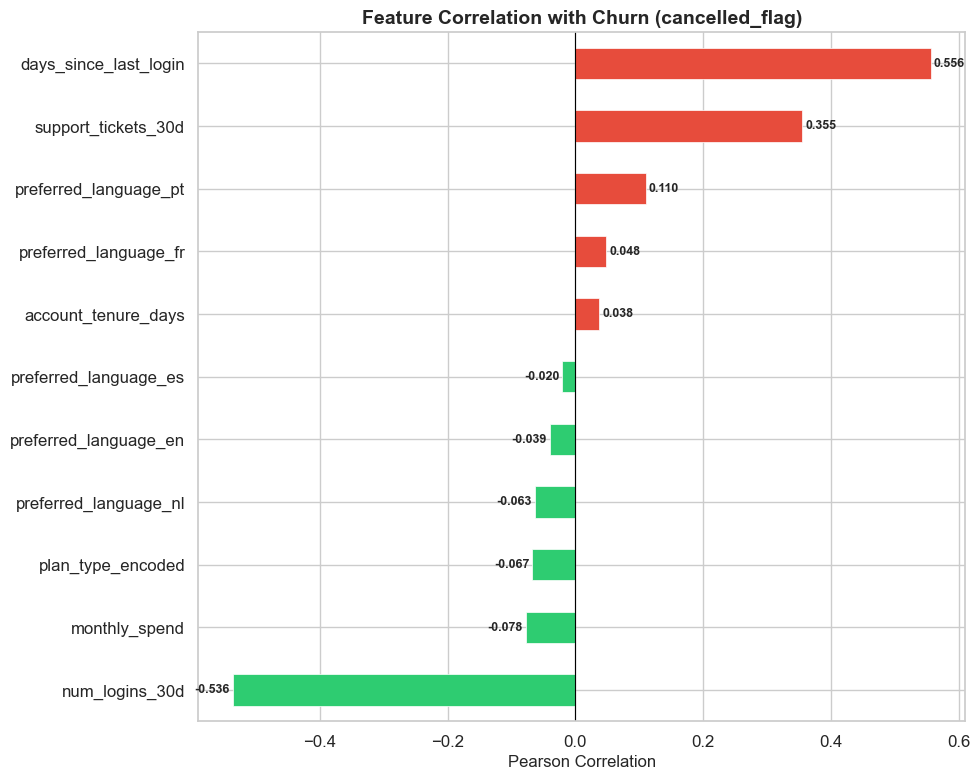

In [225]:
# Correlation with cancelled_flag
target = 'cancelled_flag'
corr_with_target = df_feats[feature_cols + [target]].corr()[target].drop(target).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in corr_with_target.values]
corr_with_target.plot.barh(ax=ax, color=colors, edgecolor='white', linewidth=0.5)
ax.set_title('Feature Correlation with Churn (cancelled_flag)', fontweight='bold', fontsize=14)
ax.set_xlabel('Pearson Correlation')
ax.axvline(0, color='black', linewidth=0.8)

# Annotate values
for i, (val, name) in enumerate(zip(corr_with_target.values, corr_with_target.index)):
    ax.text(val + 0.005 if val >= 0 else val - 0.005, i,
            f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right',
            fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

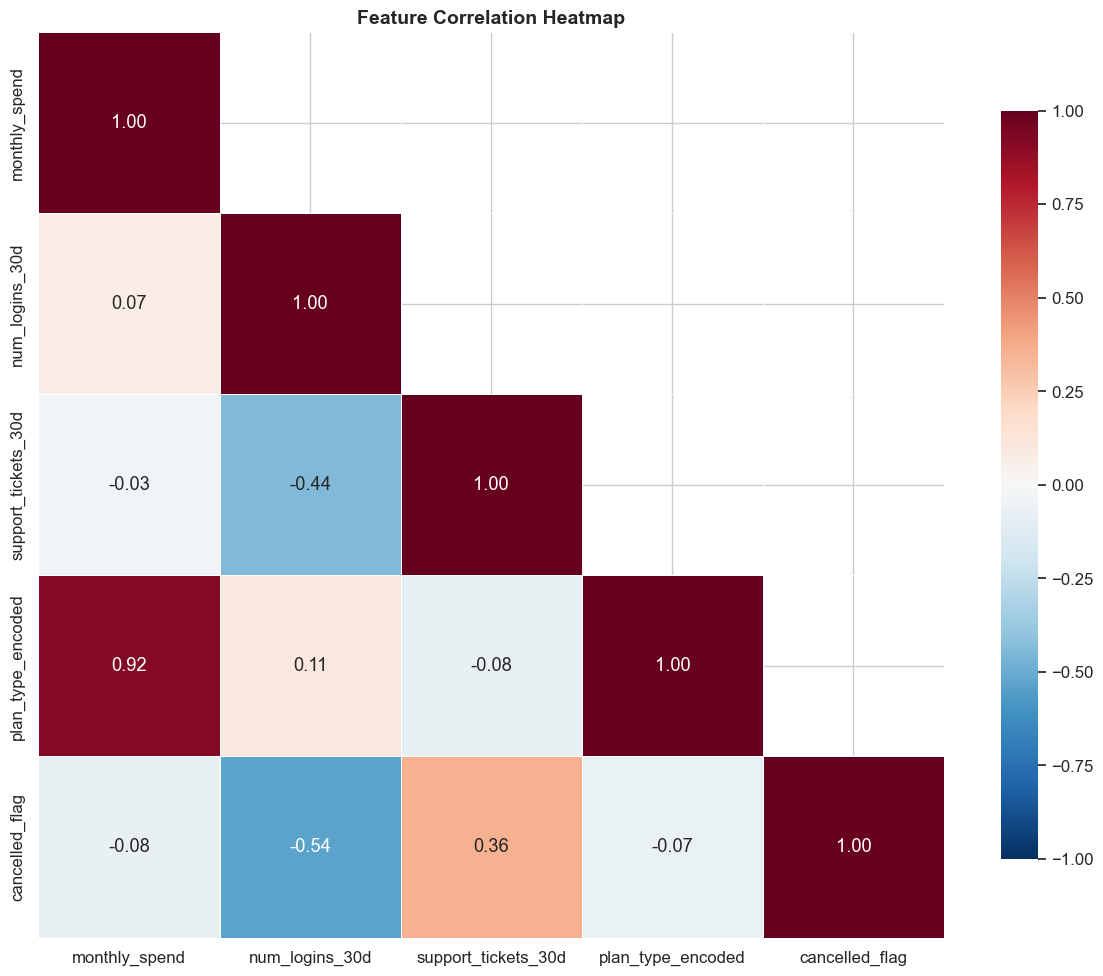

In [226]:
# Correlation heatmap of engineered features
heatmap_cols = ['monthly_spend', 'num_logins_30d', 'support_tickets_30d',
                'plan_type_encoded', 'cancelled_flag']

corr_matrix = df_feats[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, linecolor='white',
            square=True, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

## Summary

### Cleaning Applied

| Step | Issue | Action | Rows Affected |
|------|-------|--------|--------------|
| 2.1 | `internal_import_batch` | Dropped column | All |
| 2.2 | Exact duplicate rows | Dropped duplicates (keep first) | 3 pairs |
| 2.3 | Future `signup_date` (cust_0140) | Dropped row | 1 |
| 2.4 | Future `last_login_date` (cust_0202) | Set to NaT → imputed | 1 |
| 2.5 | Login before signup (cust_0166) | Set login = signup | 1 |
| 2.6 | Negative `monthly_spend` | Set to NaN → imputed with plan-type median | 2 |
| 2.7 | Missing numerics | Imputed with plan-type median | 3 |

### Features Engineered

| Feature | Source | Type | Rationale |
|---------|--------|------|-----------|
| `monthly_spend` | original | Numeric | Core value metric |
| `num_logins_30d` | original | Numeric | Activity level |
| `support_tickets_30d` | original | Numeric | Frustration signal |
| `account_tenure_days` | signup_date | Numeric | Longer tenure → more invested |
| `days_since_last_login` | last_login_date | Numeric | Longer absence → higher churn risk |
| `plan_type_encoded` | plan_type | Ordinal | Tier hierarchy |
| `preferred_language_*` | preferred_language | Binary (5) | One-hot encoded |

### Output Files

| File | Purpose |
|------|---------|
| `data/processed/notebooks/historical_clean.csv` | Cleaned data, original columns |
| `data/processed/notebooks/historical_feats.csv` | Cleaned + engineered features, ready for modeling |

## 6. Modeling Setup

In [227]:
# Now we load the engineered features, prepare the features (`X`) and target (`y`), and perform an **80/20 Stratified Split**.
# We will also apply `StandardScaler` to ensure features are on the same scale (important for Logistic Regression).

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score, roc_auc_score, f1_score, precision_score, recall_score, classification_report, PrecisionRecallDisplay, RocCurveDisplay

# Separate features and target
X = df_feats.drop(columns=['customer_id', 'cancelled_flag'])
y = df_feats['cancelled_flag'].astype(int)

# 80/20 Stratified Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train set: {X_train.shape[0]} rows (Churn rate: {y_train.mean():.1%})")
print(f"Test set: {X_test.shape[0]} rows (Churn rate: {y_test.mean():.1%})")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)
print("Features scaled using StandardScaler")

Train set: 191 rows (Churn rate: 26.2%)
Test set: 48 rows (Churn rate: 27.1%)
Features scaled using StandardScaler


## 7. Baseline Model (Raw Logistic Regression)

In [228]:
from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(class_weight='balanced', random_state=42)
baseline_model.fit(X_train_scaled, y_train)

# Evaluate on Test set
y_pred_base = baseline_model.predict(X_test_scaled)
y_prob_base = baseline_model.predict_proba(X_test_scaled)[:, 1]

def evaluate_model(name, y_true, y_pred, y_prob):
    pr_auc = average_precision_score(y_true, y_prob)
    roc_auc = roc_auc_score(y_true, y_prob)
    f1 = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    
    print(f"=== {name} (Test Set) ===")
    print(f"PR-AUC:    {pr_auc:.4f}")
    print(f"ROC-AUC:   {roc_auc:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print("-" * 25)
    return {'PR-AUC': pr_auc, 'ROC-AUC': roc_auc, 'F1': f1, 'Precision': prec, 'Recall': rec}

base_metrics = evaluate_model("Baseline LR", y_test, y_pred_base, y_prob_base)

=== Baseline LR (Test Set) ===
PR-AUC:    0.5638
ROC-AUC:   0.7253
F1 Score:  0.5625
Precision: 0.4737
Recall:    0.6923
-------------------------


## 8. Hyperparameter Tuning with Optuna

In [229]:
# We will use Optuna to tune Logistic Regression, Random Forest, and XGBoost.
# We optimize the **PR-AUC** using a 5-fold Stratified CV on the *training set* only.

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING) # Suppress extensive logs

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def tune_model(objective_func, n_trials=50):
    study = optuna.create_study(direction="maximize")
    study.optimize(objective_func, n_trials=n_trials)
    print(f"Best CV PR-AUC: {study.best_value:.4f}")
    print("Best params:", study.best_params)
    return study.best_params

### 8.1 Tuned Logistic Regression

In [230]:
def lr_objective(trial):
    params = {
        'C': trial.suggest_float('C', 1e-4, 10.0, log=True),
        'penalty': trial.suggest_categorical('penalty', ['l2']), # l2 compatible with lbfgs/liblinear
        'solver': trial.suggest_categorical('solver', ['lbfgs', 'liblinear']),
        'class_weight': 'balanced',
        'random_state': 42,
        'max_iter': 1000
    }
    model = LogisticRegression(**params)
    # Using 'average_precision' for PR-AUC
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='average_precision')
    return scores.mean()

print("Tuning Logistic Regression...")
best_lr_params = tune_model(lr_objective, n_trials=30)
best_lr_params['class_weight'] = 'balanced'
best_lr_params['random_state'] = 42
best_lr_params['max_iter'] = 1000

Tuning Logistic Regression...
Best CV PR-AUC: 0.7750
Best params: {'C': 0.001974816917171517, 'penalty': 'l2', 'solver': 'liblinear'}


### 8.2 Tuned Random Forest

In [231]:
from sklearn.ensemble import RandomForestClassifier

def rf_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'class_weight': 'balanced',
        'random_state': 42
    }
    model = RandomForestClassifier(**params)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='average_precision')
    return scores.mean()

print("Tuning Random Forest...")
best_rf_params = tune_model(rf_objective, n_trials=30)
best_rf_params['class_weight'] = 'balanced'
best_rf_params['random_state'] = 42

Tuning Random Forest...
Best CV PR-AUC: 0.7523
Best params: {'n_estimators': 266, 'max_depth': 4, 'min_samples_split': 4, 'min_samples_leaf': 4}


### 8.3 Tuned XGBoost

In [232]:
import xgboost as xgb

# Calculate scale_pos_weight
scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'scale_pos_weight': scale_pos_weight,
        'random_state': 42,
        'eval_metric': 'logloss'
    }
    model = xgb.XGBClassifier(**params)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='average_precision')
    return scores.mean()

print("Tuning XGBoost...")
best_xgb_params = tune_model(xgb_objective, n_trials=30)
best_xgb_params['scale_pos_weight'] = scale_pos_weight
best_xgb_params['random_state'] = 42
best_xgb_params['eval_metric'] = 'logloss'

Tuning XGBoost...
Best CV PR-AUC: 0.7159
Best params: {'n_estimators': 236, 'max_depth': 8, 'learning_rate': 0.01278213030773026, 'subsample': 0.5619150544245504, 'colsample_bytree': 0.7030123974967515}


## 9. Final Evaluation & Model Selection

In [233]:
# Train final models
tuned_lr = LogisticRegression(**best_lr_params).fit(X_train_scaled, y_train)
tuned_rf = RandomForestClassifier(**best_rf_params).fit(X_train_scaled, y_train)
tuned_xgb = xgb.XGBClassifier(**best_xgb_params).fit(X_train_scaled, y_train)

# Evaluate
print("\n" + "="*40)
lr_metrics = evaluate_model("Tuned LR", y_test, tuned_lr.predict(X_test_scaled), tuned_lr.predict_proba(X_test_scaled)[:, 1])
rf_metrics = evaluate_model("Tuned RF", y_test, tuned_rf.predict(X_test_scaled), tuned_rf.predict_proba(X_test_scaled)[:, 1])
xgb_metrics = evaluate_model("Tuned XGBoost", y_test, tuned_xgb.predict(X_test_scaled), tuned_xgb.predict_proba(X_test_scaled)[:, 1])

# Comparison DataFrame
comp_df = pd.DataFrame([base_metrics, lr_metrics, rf_metrics, xgb_metrics], 
                        index=['Baseline LR', 'Tuned LR', 'Tuned RF', 'Tuned XGBoost'])
display(comp_df.style.highlight_max(color='gray', axis=0))


=== Tuned LR (Test Set) ===
PR-AUC:    0.6291
ROC-AUC:   0.7758
F1 Score:  0.5263
Precision: 0.4000
Recall:    0.7692
-------------------------
=== Tuned RF (Test Set) ===
PR-AUC:    0.5413
ROC-AUC:   0.7275
F1 Score:  0.6452
Precision: 0.5556
Recall:    0.7692
-------------------------
=== Tuned XGBoost (Test Set) ===
PR-AUC:    0.4722
ROC-AUC:   0.7077
F1 Score:  0.6452
Precision: 0.5556
Recall:    0.7692
-------------------------


,PR-AUC,ROC-AUC,F1,Precision,Recall
Baseline LR,0.563780,0.725275,0.562500,0.473684,0.692308
Tuned LR,0.629076,0.775824,0.526316,0.400000,0.769231
Tuned RF,0.541252,0.727473,0.645161,0.555556,0.769231
Tuned XGBoost,0.472187,0.707692,0.645161,0.555556,0.769231


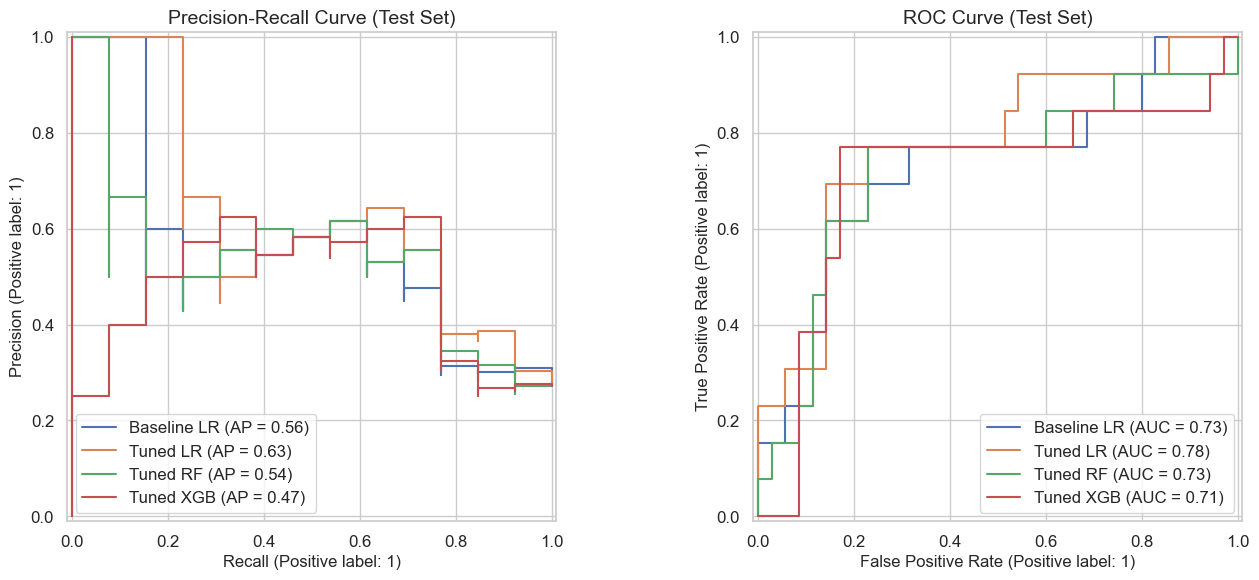

In [234]:
# Plot PR and ROC Curves for best models
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Precision-Recall Curve
PrecisionRecallDisplay.from_estimator(baseline_model, X_test_scaled, y_test, ax=ax1, name="Baseline LR")
PrecisionRecallDisplay.from_estimator(tuned_lr, X_test_scaled, y_test, ax=ax1, name="Tuned LR")
PrecisionRecallDisplay.from_estimator(tuned_rf, X_test_scaled, y_test, ax=ax1, name="Tuned RF")
PrecisionRecallDisplay.from_estimator(tuned_xgb, X_test_scaled, y_test, ax=ax1, name="Tuned XGB")
ax1.set_title("Precision-Recall Curve (Test Set)")

# ROC Curve
RocCurveDisplay.from_estimator(baseline_model, X_test_scaled, y_test, ax=ax2, name="Baseline LR")
RocCurveDisplay.from_estimator(tuned_lr, X_test_scaled, y_test, ax=ax2, name="Tuned LR")
RocCurveDisplay.from_estimator(tuned_rf, X_test_scaled, y_test, ax=ax2, name="Tuned RF")
RocCurveDisplay.from_estimator(tuned_xgb, X_test_scaled, y_test, ax=ax2, name="Tuned XGB")
ax2.set_title("ROC Curve (Test Set)")

plt.tight_layout()
plt.show()

## 10. Model Artifact & Next Steps

Based on the evaluation above, the best model will be saved as an artifact for scoring the current customers.

**Saved Artifact Format:**
```python
artifact = {
    "model": best_model,
    "dsll_median": median_dsll,
    "feature_cols": list(X.columns)
}
```

## 11. Model Explainability with SHAP

In [235]:
# We will use SHAP (SHapley Additive exPlanations) to interpret our best model. 
# SHAP values explain the impact of each feature on the model's output, allowing us to see exactly 
# why the model predicts churn for specific customers.

import shap
shap.initjs()

# We'll use the Tuned XGBoost model for SHAP since tree-based models have excellent SHAP support
best_model_for_shap = tuned_xgb
explainer = shap.TreeExplainer(best_model_for_shap)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_scaled)
print("SHAP values calculated")

SHAP values calculated


### 11.1 Global Feature Importance
The summary plot shows the most important features and how their values impact the prediction (red = high value, blue = low value).

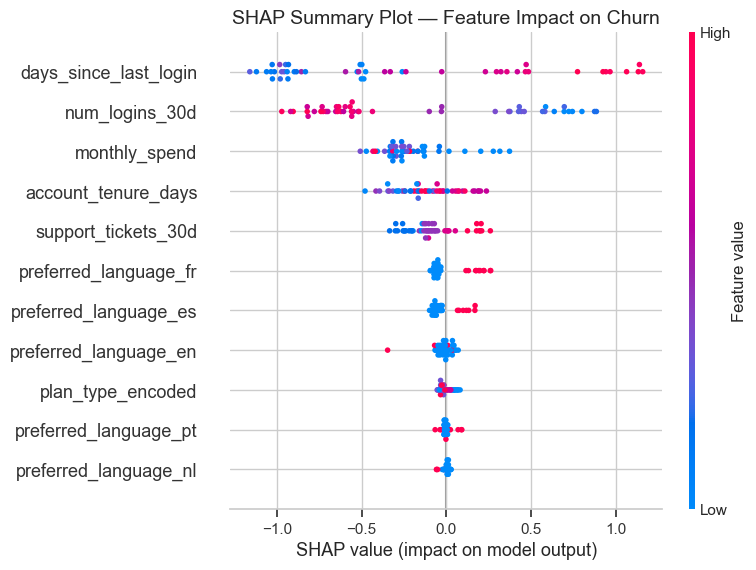

In [236]:
# Summary Plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_scaled, feature_names=X_test.columns, show=False)
plt.title("SHAP Summary Plot — Feature Impact on Churn")
plt.tight_layout()
plt.show()

### 11.2 Individual Customer Explainability
Let's look at the customer in the test set with the **highest probability of churn**, and see *why* the model flagged them.

Customer Index: 39
Predicted Churn Probability: 88.8%


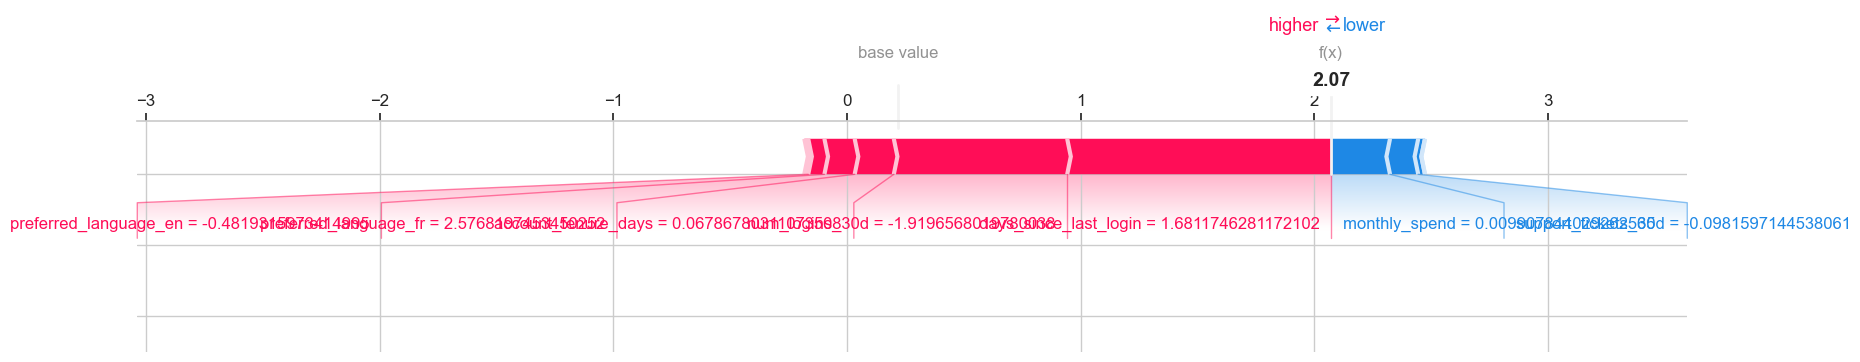

In [237]:
# Find the customer with the highest predicted churn probability in the test set
highest_risk_idx = tuned_xgb.predict_proba(X_test_scaled)[:, 1].argmax()
highest_risk_prob = tuned_xgb.predict_proba(X_test_scaled)[highest_risk_idx, 1]

print(f"Customer Index: {highest_risk_idx}")
print(f"Predicted Churn Probability: {highest_risk_prob:.1%}")

# Generate force plot for this specific customer
shap.force_plot(
    explainer.expected_value, 
    shap_values[highest_risk_idx,:], 
    X_test_scaled.iloc[highest_risk_idx,:], 
    feature_names=X_test.columns,
    matplotlib=True
)
plt.show()